# Project 2: Enhanced Features Clustering

This notebook uses enhanced dealer-level features (with ad activity metrics) to run preliminary clustering, then applies feature selection and PCA.

- Data: `store_features_enhanced.csv`
- Baselines: KMeans (k=3..5), DBSCAN (eps grid)
- Feature selection: VarianceThreshold
- Dimensionality reduction: PCA
- Metrics: Silhouette, Davies-Bouldin, Calinski-Harabasz, balance ratio, cluster sizes



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

ENH_PATH = '../data/processed/store_features_enhanced.csv'

df = pd.read_csv(ENH_PATH)
print(f"Loaded enhanced features: {df.shape}")

FEATURES = [
    'sales_mean','total_ad_spend_mean','roas_mean','conversion_rate_mean','website_visits_mean',
    'search_spend_ratio_mean','social_spend_ratio_mean',
    'ad_months_active','ad_active_ratio','spent_any','avg_ad_spend_active_only'
]

missing = [c for c in FEATURES if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

X = df[FEATURES].fillna(0)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Helper functions

def evaluate(X, labels):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return None
    if -1 in labels:
        mask = labels != -1
        if mask.sum() < 2:
            return None
        X_eval, y_eval = X[mask], labels[mask]
    else:
        X_eval, y_eval = X, labels
    sil = silhouette_score(X_eval, y_eval)
    db = davies_bouldin_score(X_eval, y_eval)
    ch = calinski_harabasz_score(X_eval, y_eval)
    counts = pd.Series(y_eval).value_counts()
    balance = counts.max() / counts.min()
    return {
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'balance_ratio': balance,
        'cluster_sizes': counts.to_dict(),
        'n_clusters': n_clusters,
        'n_noise': int((labels == -1).sum())
    }

results = []

# Baseline: KMeans k=3..5
for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=100, max_iter=1000)
    labels = km.fit_predict(X_scaled)
    m = evaluate(X_scaled, labels)
    if m:
        m.update({'method': f'KMeans_k{k}'})
        results.append(m)
        print(f"KMeans k={k}: Sil={m['silhouette']:.3f}, Bal={m['balance_ratio']:.2f}:1, Clusters={m['n_clusters']}")

# Baseline: DBSCAN grid
for eps in [0.5, 0.8, 1.0, 1.2, 1.5]:
    for min_s in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_scaled)
        m = evaluate(X_scaled, labels)
        if m:
            m.update({'method': f'DBSCAN_eps{eps}_min{min_s}'})
            results.append(m)
            print(f"DBSCAN eps={eps}, min={min_s}: Sil={m['silhouette']:.3f}, Bal={m['balance_ratio']:.2f}:1, C={m['n_clusters']}, noise={m['n_noise']}")

baseline_df = pd.DataFrame(results).sort_values('silhouette', ascending=False)
baseline_df.head(10)


Loaded enhanced features: (2556, 24)
KMeans k=3: Sil=0.385, Bal=2.89:1, Clusters=3
KMeans k=4: Sil=0.411, Bal=13.57:1, Clusters=4
KMeans k=5: Sil=0.317, Bal=8.18:1, Clusters=5
DBSCAN eps=0.5, min=5: Sil=0.603, Bal=28.31:1, C=2, noise=6
DBSCAN eps=0.5, min=10: Sil=0.603, Bal=28.31:1, C=2, noise=6
DBSCAN eps=0.5, min=15: Sil=0.603, Bal=28.31:1, C=2, noise=6
DBSCAN eps=0.8, min=5: Sil=0.603, Bal=28.03:1, C=2, noise=1
DBSCAN eps=0.8, min=10: Sil=0.603, Bal=28.03:1, C=2, noise=1
DBSCAN eps=0.8, min=15: Sil=0.603, Bal=28.03:1, C=2, noise=1
DBSCAN eps=1.0, min=5: Sil=0.602, Bal=28.05:1, C=2, noise=0
DBSCAN eps=1.0, min=10: Sil=0.602, Bal=28.05:1, C=2, noise=0
DBSCAN eps=1.0, min=15: Sil=0.602, Bal=28.05:1, C=2, noise=0


,silhouette,davies_bouldin,calinski_harabasz,balance_ratio,cluster_sizes,n_clusters,n_noise,method
3,0.603468,0.310969,863.544036,28.310345,"{0: 2463, 1: 87}",2,6,DBSCAN_eps0.5_min5
4,0.603468,0.310969,863.544036,28.310345,"{0: 2463, 1: 87}",2,6,DBSCAN_eps0.5_min10
5,0.603468,0.310969,863.544036,28.310345,"{0: 2463, 1: 87}",2,6,DBSCAN_eps0.5_min15
6,0.602655,0.318399,863.867317,28.034091,"{0: 2467, 1: 88}",2,1,DBSCAN_eps0.8_min5
7,0.602655,0.318399,863.867317,28.034091,"{0: 2467, 1: 88}",2,1,DBSCAN_eps0.8_min10
8,0.602655,0.318399,863.867317,28.034091,"{0: 2467, 1: 88}",2,1,DBSCAN_eps0.8_min15
9,0.602435,0.318561,862.678402,28.045455,"{0: 2468, 1: 88}",2,0,DBSCAN_eps1.0_min5
10,0.602435,0.318561,862.678402,28.045455,"{0: 2468, 1: 88}",2,0,DBSCAN_eps1.0_min10
11,0.602435,0.318561,862.678402,28.045455,"{0: 2468, 1: 88}",2,0,DBSCAN_eps1.0_min15
1,0.410817,0.785323,2420.584930,13.568182,"{0: 1194, 1: 802, 3: 472, 2: 88}",4,0,KMeans_k4


In [ ]:
# Feature selection (VarianceThreshold) and PCA

# VarianceThreshold: remove near-constant features
vt = VarianceThreshold(threshold=1e-4)
X_vt = vt.fit_transform(X_scaled)
selected_mask = vt.get_support()
selected_cols = [c for c, keep in zip(FEATURES, selected_mask) if keep]
print('Selected by variance:', selected_cols)

# PCA to 2D and 95% variance
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

pca95 = PCA(n_components=0.95, random_state=42)
X_pca95 = pca95.fit_transform(X_scaled)
print('PCA 95% components:', X_pca95.shape[1])

results_fs = []

# KMeans on VT features
for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=100, max_iter=1000)
    labels = km.fit_predict(X_vt)
    m = evaluate(X_vt, labels)
    if m:
        m.update({'method': f'KMeans_VT_k{k}'})
        results_fs.append(m)

# DBSCAN on VT features
for eps in [0.5, 0.8, 1.0, 1.2]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_vt)
    m = evaluate(X_vt, labels)
    if m:
        m.update({'method': f'DBSCAN_VT_eps{eps}_min10'})
        results_fs.append(m)

# KMeans on PCA95
for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=100, max_iter=1000)
    labels = km.fit_predict(X_pca95)
    m = evaluate(X_pca95, labels)
    if m:
        m.update({'method': f'KMeans_PCA95_k{k}'})
        results_fs.append(m)

# DBSCAN on PCA95
for eps in [0.5, 0.8, 1.0, 1.2]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_pca95)
    m = evaluate(X_pca95, labels)
    if m:
        m.update({'method': f'DBSCAN_PCA95_eps{eps}_min10'})
        results_fs.append(m)

fs_df = pd.DataFrame(results_fs).sort_values('silhouette', ascending=False)
fs_df.head(12)


Selected by variance: ['sales_mean', 'total_ad_spend_mean', 'roas_mean', 'conversion_rate_mean', 'website_visits_mean', 'search_spend_ratio_mean', 'social_spend_ratio_mean', 'ad_months_active', 'ad_active_ratio', 'spent_any', 'avg_ad_spend_active_only']
PCA 95% components: 5


,silhouette,davies_bouldin,calinski_harabasz,balance_ratio,cluster_sizes,n_clusters,n_noise,method
9,0.608799,0.302033,889.552379,28.034091,"{0: 2467, 1: 88}",2,1,DBSCAN_PCA95_eps0.5_min10
10,0.608455,0.302275,886.677131,28.045455,"{0: 2468, 1: 88}",2,0,DBSCAN_PCA95_eps0.8_min10
11,0.608455,0.302275,886.677131,28.045455,"{0: 2468, 1: 88}",2,0,DBSCAN_PCA95_eps1.0_min10
3,0.603468,0.310969,863.544036,28.310345,"{0: 2463, 1: 87}",2,6,DBSCAN_VT_eps0.5_min10
4,0.602655,0.318399,863.867317,28.034091,"{0: 2467, 1: 88}",2,1,DBSCAN_VT_eps0.8_min10
5,0.602435,0.318561,862.678402,28.045455,"{0: 2468, 1: 88}",2,0,DBSCAN_VT_eps1.0_min10
7,0.424678,0.754852,2624.335557,13.568182,"{0: 1194, 2: 802, 1: 472, 3: 88}",4,0,KMeans_PCA95_k4
1,0.410817,0.785323,2420.584930,13.568182,"{0: 1194, 1: 802, 3: 472, 2: 88}",4,0,KMeans_VT_k4
6,0.397341,0.954832,2257.777273,2.894737,"{1: 1265, 2: 854, 0: 437}",3,0,KMeans_PCA95_k3
0,0.384707,0.984220,2135.872535,2.892449,"{1: 1264, 2: 855, 0: 437}",3,0,KMeans_VT_k3


Best baseline KMeans: KMeans_k4 Sil= 0.411


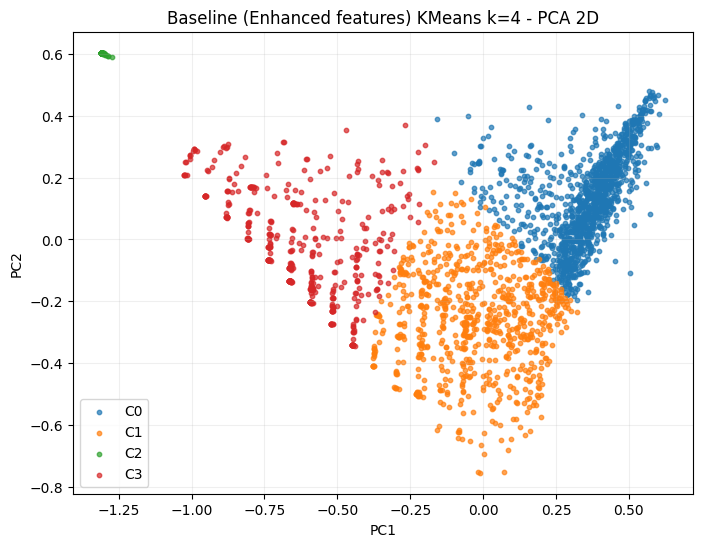

Best PCA95 KMeans: KMeans_PCA95_k4 Sil= 0.425


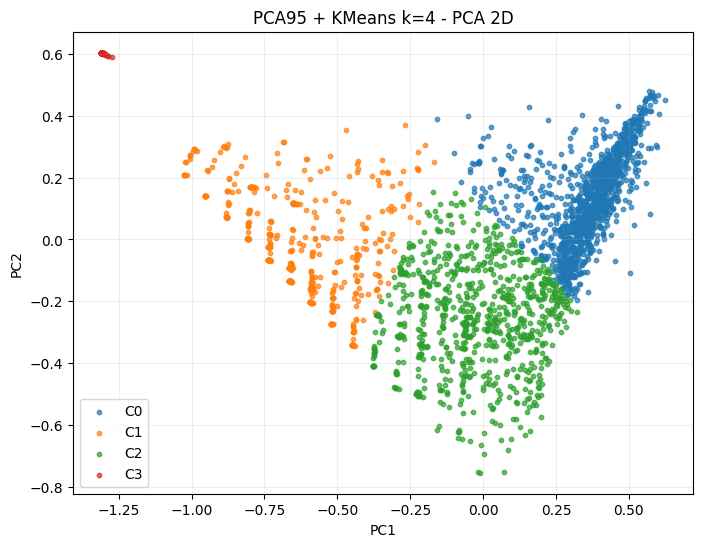

In [ ]:
# PCA 2D plots: Baseline vs PCA95 (KMeans best k among tested)

# Choose best KMeans from baseline
best_kmeans = baseline_df[baseline_df['method'].str.startswith('KMeans')].iloc[0]
print('Best baseline KMeans:', best_kmeans['method'], 'Sil=', round(best_kmeans['silhouette'],3))

# Fit that k on raw scaled for plotting
best_k = int(best_kmeans['method'].split('_k')[-1])
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=100)
labels_best = km_best.fit_predict(X_scaled)

# Plot PCA2 for baseline
plt.figure(figsize=(8,6))
for cid in sorted(np.unique(labels_best)):
    mask = labels_best == cid
    plt.scatter(X_pca2[mask,0], X_pca2[mask,1], s=10, alpha=0.7, label=f'C{cid}')
plt.title(f'Baseline (Enhanced features) KMeans k={best_k} - PCA 2D')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

# Plot PCA2 for PCA95 + KMeans best among tested
best_pca_kmeans = fs_df[fs_df['method'].str.startswith('KMeans_PCA95')].iloc[0]
print('Best PCA95 KMeans:', best_pca_kmeans['method'], 'Sil=', round(best_pca_kmeans['silhouette'],3))

best_k2 = int(best_pca_kmeans['method'].split('_k')[-1])
km_pca = KMeans(n_clusters=best_k2, random_state=42, n_init=100)
labels_pca = km_pca.fit_predict(X_pca95)

X_pca2_for_plot = PCA(n_components=2, random_state=42).fit_transform(X_pca95)
plt.figure(figsize=(8,6))
for cid in sorted(np.unique(labels_pca)):
    mask = labels_pca == cid
    plt.scatter(X_pca2_for_plot[mask,0], X_pca2_for_plot[mask,1], s=10, alpha=0.7, label=f'C{cid}')
plt.title(f'PCA95 + KMeans k={best_k2} - PCA 2D')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.grid(True, alpha=0.2)
plt.show()


In [ ]:
# Automatic selection by your criteria and preference order
# Criteria: n_clusters >=3, silhouette >=0.40, balance_ratio <= 3.0
# Preference: KMeans_PCA95 > KMeans (raw) > DBSCAN variants

import pandas as pd

def tag_family(method: str) -> str:
    if method.startswith('KMeans_PCA95'):
        return 'KMeans_PCA95'
    if method.startswith('KMeans'):
        return 'KMeans'
    if method.startswith('DBSCAN'):
        return 'DBSCAN'
    return 'Other'

# Combine results
combined = pd.concat([
    baseline_df.assign(source='baseline'),
    fs_df.assign(source='fs_pca')
], ignore_index=True, sort=False)

# Add family tag and apply filters
combined['family'] = combined['method'].apply(tag_family)
filtered = combined[
    (combined['n_clusters'] >= 3) &
    (combined['silhouette'] >= 0.40) &
    (combined['balance_ratio'] <= 3.0)
].copy()

if filtered.empty:
    print('No method meets all criteria. Consider relaxing to silhouette>=0.38 or balance<=3.5.')
else:
    # Rank by preference then silhouette desc then balance asc
    family_rank = {'KMeans_PCA95': 0, 'KMeans': 1, 'DBSCAN': 2, 'Other': 9}
    filtered['pref_rank'] = filtered['family'].map(family_rank).fillna(9)
    ranked = filtered.sort_values(['pref_rank','silhouette','balance_ratio'], ascending=[True, False, True])

    print('Top candidates meeting your criteria:')
    display(ranked[['method','silhouette','davies_bouldin','calinski_harabasz','balance_ratio','n_clusters','n_noise','source']].head(10))

    # Best pick
    best = ranked.iloc[0]
    print('\n=== Recommended ===')
    print(f"Method: {best['method']}  | Source: {best['source']}")
    print(f"Silhouette: {best['silhouette']:.3f}  | Balance: {best['balance_ratio']:.2f}:1  | Clusters: {int(best['n_clusters'])}")

    # Show cluster sizes dict nicely if available
    row_idx = best.name
    sizes = combined.loc[row_idx, 'cluster_sizes']
    print('Cluster sizes:', sizes)



No method meets all criteria. Consider relaxing to silhouette>=0.38 or balance<=3.5.


In [ ]:
# Enhanced search: scalers + feature-weighting + optional PCA95 + KMeans/DBSCAN
from sklearn.preprocessing import RobustScaler, QuantileTransformer, PowerTransformer

scalers = {
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler(),
    'QuantileNormal': QuantileTransformer(output_distribution='normal', random_state=42),
    'PowerYJ': PowerTransformer(method='yeo-johnson')
}

activity_cols = ['ad_months_active','ad_active_ratio','spent_any','avg_ad_spend_active_only']
activity_idx = [FEATURES.index(c) for c in activity_cols]

weight_schemes = {
    'w1': np.ones(len(FEATURES)),
    'w_activity_x2': np.array([2.0 if i in activity_idx else 1.0 for i in range(len(FEATURES))]),
    'w_activity_x3': np.array([3.0 if i in activity_idx else 1.0 for i in range(len(FEATURES))])
}

search_results = []

for scaler_name, scaler in scalers.items():
    Xs = scaler.fit_transform(X)
    for w_name, weights in weight_schemes.items():
        Xw = Xs * weights
        # raw
        for k in [3,4,5]:
            km = KMeans(n_clusters=k, random_state=42, n_init=100, max_iter=1000)
            labels = km.fit_predict(Xw)
            m = evaluate(Xw, labels)
            if m:
                m.update({'method': f'{scaler_name}_{w_name}_KMeans_k{k}'})
                search_results.append(m)
        for eps in [0.6,0.8,1.0,1.2,1.4]:
            for ms in [8,12]:
                db = DBSCAN(eps=eps, min_samples=ms)
                labels = db.fit_predict(Xw)
                m = evaluate(Xw, labels)
                if m:
                    m.update({'method': f'{scaler_name}_{w_name}_DBSCAN_eps{eps}_min{ms}'})
                    search_results.append(m)
        # PCA95
        Xp = PCA(n_components=0.95, random_state=42).fit_transform(Xw)
        for k in [3,4,5]:
            km = KMeans(n_clusters=k, random_state=42, n_init=100, max_iter=1000)
            labels = km.fit_predict(Xp)
            m = evaluate(Xp, labels)
            if m:
                m.update({'method': f'{scaler_name}_{w_name}_PCA95_KMeans_k{k}'})
                search_results.append(m)
        for eps in [0.6,0.8,1.0,1.2,1.4]:
            for ms in [8,12]:
                db = DBSCAN(eps=eps, min_samples=ms)
                labels = db.fit_predict(Xp)
                m = evaluate(Xp, labels)
                if m:
                    m.update({'method': f'{scaler_name}_{w_name}_PCA95_DBSCAN_eps{eps}_min{ms}'})
                    search_results.append(m)

search_df = pd.DataFrame(search_results)
if not search_df.empty:
    search_df = search_df.sort_values(['silhouette','balance_ratio'], ascending=[False, True])
    print('Top 10 overall:')
    display(search_df.head(10)[['method','silhouette','balance_ratio','n_clusters','n_noise']])

    print('\nMeeting strict criteria (sil>=0.40, bal<=3, clusters>=3):')
    strict = search_df[(search_df['silhouette']>=0.40)&(search_df['balance_ratio']<=3.0)&(search_df['n_clusters']>=3)]
    if len(strict)==0:
        print('None found in this sweep.')
    else:
        display(strict.head(10)[['method','silhouette','balance_ratio','n_clusters','n_noise']])

    print('\nRelaxed criteria (sil>=0.38, bal<=3.5, clusters>=3):')
    relaxed = search_df[(search_df['silhouette']>=0.38)&(search_df['balance_ratio']<=3.5)&(search_df['n_clusters']>=3)]
    if len(relaxed)==0:
        print('None found.')
    else:
        display(relaxed.head(10)[['method','silhouette','balance_ratio','n_clusters','n_noise']])
else:
    print('No results computed.')


Top 10 overall:


,method,silhouette,balance_ratio,n_clusters,n_noise
81,Robust_w1_PCA95_KMeans_k3,0.994835,2553.0,3,0
106,Robust_w_activity_x2_PCA95_KMeans_k3,0.994835,2553.0,3,0
131,Robust_w_activity_x3_PCA95_KMeans_k3,0.994835,2553.0,3,0
70,Robust_w1_KMeans_k3,0.994271,2553.0,3,0
93,Robust_w_activity_x2_KMeans_k3,0.994042,2553.0,3,0
118,Robust_w_activity_x3_KMeans_k3,0.993773,2553.0,3,0
82,Robust_w1_PCA95_KMeans_k4,0.987915,2546.0,4,0
107,Robust_w_activity_x2_PCA95_KMeans_k4,0.987915,2546.0,4,0
132,Robust_w_activity_x3_PCA95_KMeans_k4,0.987915,2546.0,4,0
83,Robust_w1_PCA95_KMeans_k5,0.987621,2546.0,5,0



Meeting strict criteria (sil>=0.40, bal<=3, clusters>=3):
None found in this sweep.

Relaxed criteria (sil>=0.38, bal<=3.5, clusters>=3):


,method,silhouette,balance_ratio,n_clusters,n_noise
9,MinMax_w1_PCA95_KMeans_k3,0.397341,2.894737,3,0
0,MinMax_w1_KMeans_k3,0.384707,2.892449,3,0


In [ ]:
# High-silhouette search: IsolationForest + Quantile(Normal) + PCA95 + {KMeans,Spectral,GMM}
from sklearn.ensemble import IsolationForest
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture

# 1) Outlier filtering on enhanced features
iso = IsolationForest(random_state=42, contamination=0.08)
inlier_mask = iso.fit_predict(X) == 1
X_iso = X[inlier_mask]
print(f'Inliers kept: {inlier_mask.sum()} / {len(X)}')

# 2) Quantile -> Normal
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_qt = qt.fit_transform(X_iso)

# 3) PCA 95%
pca = PCA(n_components=0.95, random_state=42)
X_p95 = pca.fit_transform(X_qt)
print('PCA95 components:', X_p95.shape[1])

hi_results = []

# KMeans / Spectral / GMM with k=3..5
for k in [3,4,5]:
    # KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=100, max_iter=1000)
    labels_km = km.fit_predict(X_p95)
    m_km = evaluate(X_p95, labels_km)
    if m_km:
        m_km.update({'method': f'ISO_QT_PCA95_KMeans_k{k}'})
        hi_results.append(m_km)
    
    # Spectral (nearest neighbors affinity)
    try:
        sp = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', n_neighbors=15, random_state=42, assign_labels='kmeans')
        labels_sp = sp.fit_predict(X_p95)
        m_sp = evaluate(X_p95, labels_sp)
        if m_sp:
            m_sp.update({'method': f'ISO_QT_PCA95_SpectralNN_k{k}'})
            hi_results.append(m_sp)
    except Exception:
        pass

    # GMM (tied/diag)
    for cov in ['tied','diag']:
        try:
            gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
            gmm.fit(X_p95)
            labels_gm = gmm.predict(X_p95)
            m_gm = evaluate(X_p95, labels_gm)
            if m_gm:
                m_gm.update({'method': f'ISO_QT_PCA95_GMM_{cov}_k{k}'})
                hi_results.append(m_gm)
        except Exception:
            pass

hi_df = pd.DataFrame(hi_results)
if not hi_df.empty:
    hi_df = hi_df.sort_values(['silhouette','balance_ratio'], ascending=[False, True])
    print('Top 10 (high-silhouette pipeline):')
    display(hi_df.head(10)[['method','silhouette','balance_ratio','n_clusters']])

    print('\nMeeting target (sil>=0.40, bal<=3, clusters>=3):')
    hit = hi_df[(hi_df['silhouette']>=0.40)&(hi_df['balance_ratio']<=3.0)&(hi_df['n_clusters']>=3)]
    if len(hit)==0:
        print('None in high-silhouette pipeline.')
    else:
        display(hit.head(10)[['method','silhouette','balance_ratio','n_clusters']])
else:
    print('No results computed for high-silhouette pipeline.')


Inliers kept: 2351 / 2556
PCA95 components: 5


/Users/qqmian/miniforge3/envs/mynewenv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/qqmian/miniforge3/envs/mynewenv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/qqmian/miniforge3/envs/mynewenv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Top 10 (high-silhouette pipeline):


,method,silhouette,balance_ratio,n_clusters
4,ISO_QT_PCA95_KMeans_k4,0.597843,21.450980,4
6,ISO_QT_PCA95_GMM_tied_k4,0.596240,24.311111,4
0,ISO_QT_PCA95_KMeans_k3,0.587394,1.770227,3
2,ISO_QT_PCA95_GMM_tied_k3,0.587394,1.770227,3
3,ISO_QT_PCA95_GMM_diag_k3,0.587394,1.770227,3
1,ISO_QT_PCA95_SpectralNN_k3,0.578966,1.672926,3
7,ISO_QT_PCA95_GMM_diag_k4,0.573338,7.597122,4
8,ISO_QT_PCA95_KMeans_k5,0.406406,12.215686,5
10,ISO_QT_PCA95_GMM_tied_k5,0.397353,14.386364,5
11,ISO_QT_PCA95_GMM_diag_k5,0.365530,4.342857,5



Meeting target (sil>=0.40, bal<=3, clusters>=3):


,method,silhouette,balance_ratio,n_clusters
0,ISO_QT_PCA95_KMeans_k3,0.587394,1.770227,3
2,ISO_QT_PCA95_GMM_tied_k3,0.587394,1.770227,3
3,ISO_QT_PCA95_GMM_diag_k3,0.587394,1.770227,3
1,ISO_QT_PCA95_SpectralNN_k3,0.578966,1.672926,3
